In [ ]:
temp_resid <- read.csv("data/temp_resid.csv", row.names = 1)
temp_res <- temp_resid$temp_deseasoned
price_resid <- read.csv("data/price_resid.csv", row.names = 1)
price_res <- price_resid$price_deseasoned


Starting qmle for carma ... 


Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calculate."):
"
YUIMA: quasi likelihood is too small to calculate.
"
Warning message in yuima.warn("quasi likelihood is too small to calcu


 Stationarity condition is satisfied...
 Starting Estimation Increments ...


Warning message in yuima.warn("The Derivatives for recovering noise have been performed numerically."):
"
YUIMA: The Derivatives for recovering noise have been performed numerically.
"


b0         a2         a1 
45.8994240  0.3223718  2.3521281

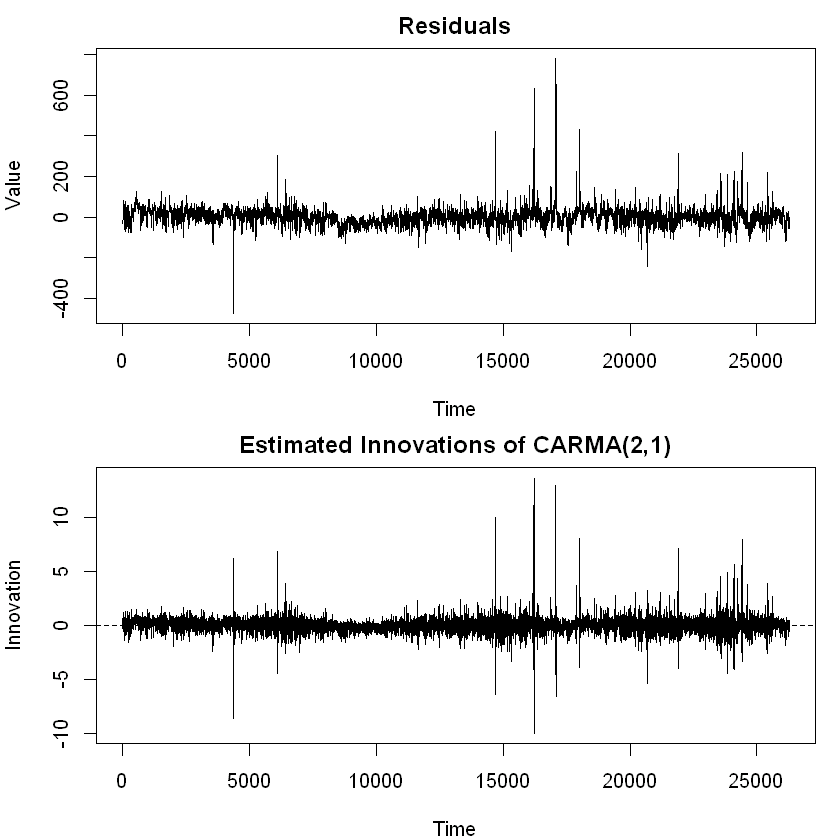

In [6]:
library(yuima)
library(zoo)

price_resid <- read.csv("data/price_resid.csv", row.names = 1)
price_res <- as.numeric(price_resid$price_deseasoned)

data_price <- setData(matrix(price_res, ncol = 1))

mod_carma_21 <- setCarma(p = 2, q = 0)
yu_price <- setYuima(model = mod_carma_21, data = data_price)

fit_price <- qmle(
  yuima = yu_price,
  start = list(a1 = 1.29572266, a2 = 0.032375392484936795,b0=1),
  joint = TRUE, #all parameters estimated together
  method = "Nelder-Mead", #algorithm to optimize the likelihood
  Est.Incr = "Incr"   
)

y_obs <- as.numeric(coredata(get.zoo.data(yu_price)[[1]]))

eps_hat <- as.numeric(coredata(fit_price@Incr.Lev))

n <- min(length(y_obs), length(eps_hat))
y_obs2 <- y_obs[1:n]
eps_hat2 <- eps_hat[1:n]

par(mfrow = c(2,1), mar = c(4,4,2,1))

plot(y_obs2, type = "l",
     main = "Residuals",
     xlab = "Time", ylab = "Value")

plot(eps_hat2, type = "l",
     main = "Estimated Innovations of CARMA(2,1)",
     xlab = "Time", ylab = "Innovation")
abline(h = 0, lty = 2)
coef(fit_price)

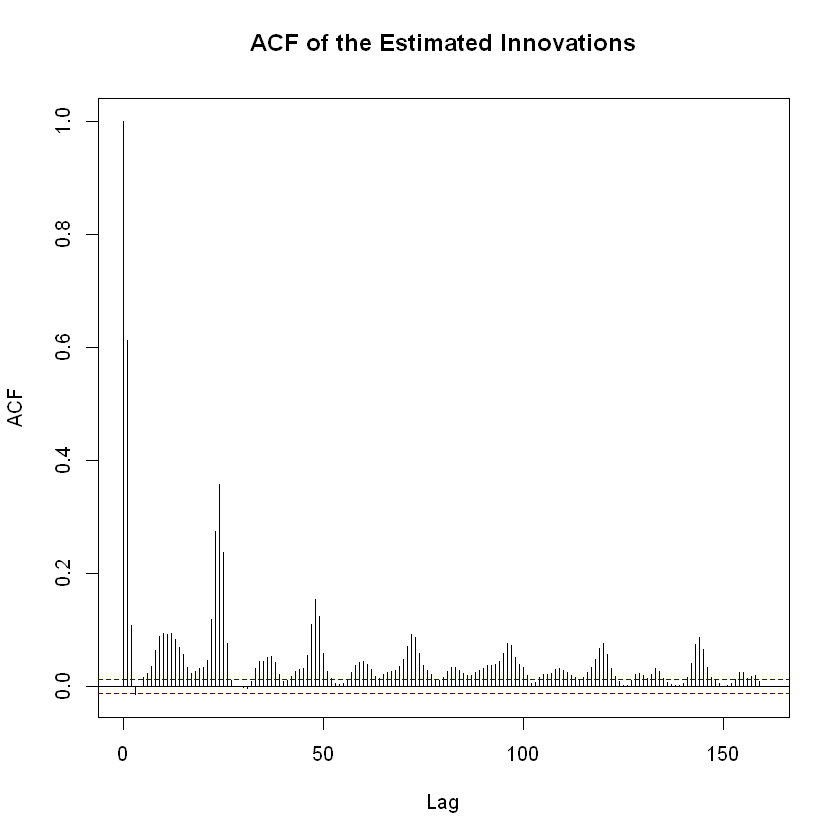

In [7]:
res_carma <- as.numeric(coredata(fit_price@Incr.Lev))
acf(res_carma,main = "ACF of the Estimated Innovations",lag.max = 160)

In [ ]:
#test